## Etude de données issues de plusieurs runs
Dans ce notebook on s'interesse à plusieurs run où on cherche à mettre en évidence le J/Psi

In [1]:
import math
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import hist
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import uproot
import vector
import time

vector.register_awkward()

print("uproot version", uproot.__version__)
print("awkward version", ak.__version__)
print("numpy version", np.__version__)
print("matplotlib version", matplotlib.__version__)
print("hist version", hist.__version__)
print("vector version", vector.__version__)
!ls -alh /pbs/throng/training/nantes-m2-rps-exp/data/*291263*

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2
-rwxrwxr-x 1 2830 training 414M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.data.root
-rwxrwxr-x 1 2830 training  26M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root


In [2]:
import uproot
import glob
import os
liens = []
# Chemin vers le dossier contenant les fichiers
folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data/"

# Trouver tous les fichiers .data.root
file_paths = glob.glob(os.path.join(folder_path, "*.data.root"))

# Vérifier si des fichiers ont été trouvés
if not file_paths:
    print("Aucun fichier .data.root trouvé.")
else:
    print(f"{len(file_paths)} fichiers trouvés.")

# Parcourir et ouvrir chaque fichier pour afficher ses clés
for file_path in file_paths:
    liens.append(file_path)
print(liens[:2])


166 fichiers trouvés.
['/pbs/throng/training/nantes-m2-rps-exp/data/run290428.data.root', '/pbs/throng/training/nantes-m2-rps-exp/data/run291447.data.root']


## Définitions des fonctions utilisées pour les exploitations de données

In [3]:

def donnees_masses_invarientes (lien_du_run):

##Cette fonction prend en entrée le lien d'un RUN et en ressort les valeurs de masses invariantes pour ce run sous forme de liste
    file = uproot.open(lien_du_run)
    file.keys()
    events = file["eventsTree"]
    m = events.arrays(
        [
            "nMuons",
            "Muon_Px",
            "Muon_Py",
            "Muon_Pz",
            "Muon_Charge",
            "Muon_E",
            "isCMUL",
            "zVtx",
            "Muon_matchedTrgThreshold",
            "isCMSH",
            "isCMLL",
            "Muon_yDCA",
            "Muon_thetaAbs",
        ],
        how="zip",
    )
    
    filtered_events = m[(m.nMuons >= 2) & (abs(m.zVtx) < 10) & (m.isCMUL)]
    filtered_events_back = m[(m.nMuons >= 2) & (abs(m.zVtx) < 10)]
    
    # Initialiser les vecteurs des muons
    muon_vectors = ak.zip(
        {
            "px": filtered_events.Muon.Px,
            "py": filtered_events.Muon.Py,
            "pz": filtered_events.Muon.Pz,
            "E": filtered_events.Muon.E,
            "matchedTrgThreshold": filtered_events.Muon.matchedTrgThreshold,
            "DCA": filtered_events.Muon.yDCA,
            "charge": filtered_events.Muon.Charge,
            "theta": filtered_events.Muon.thetaAbs,
        },
        with_name="Momentum4D",
    )

    
    # Combinaisons de paires
    muon_pairs = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
    
    # Paires de charges opposées et filtrage
    opposite_charge_pairs = muon_pairs[
        (muon_pairs.muon1.charge != muon_pairs.muon2.charge)
        & (muon_pairs.muon1.matchedTrgThreshold == 2)
        & (muon_pairs.muon2.matchedTrgThreshold == 2)
        & (muon_pairs.muon1.theta <= 10)
        & (muon_pairs.muon2.theta <= 10)
        & (muon_pairs.muon1.theta >= 3)
        & (muon_pairs.muon2.theta >= 3)
        & (muon_pairs.muon1.eta <= -2.5)
        & (muon_pairs.muon2.eta <= -2.5)
        & (muon_pairs.muon2.eta >= -4)
        & (muon_pairs.muon1.eta >= -4)
    ]
    
    # Calcul des masses invariantes et de la rapidité
    masses_opposite = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).mass
    y_pair = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).rapidity
    
    # Appliquer le filtre de rapidité
    filtered_masses = masses_opposite[(y_pair <= -2.5) & (y_pair >= -4)]
    
    # Aplatir les données et filtrer les masses entre 0 et 10 GeV
    flattened_opposite = ak.flatten(filtered_masses[(filtered_masses >= 0) & (filtered_masses <= 10)], axis=None)
    print("---> Pour le run n°", lien_du_run[47:53], ",le nombre de paires considéré est :", len(flattened_opposite))
    return (flattened_opposite)

def graph_masses_invariantes (données): 
    # Calcul des histogrammes avec numpy
    bins = 1000
    hist_opposite, bin_edges = np.histogram(données, bins=bins, range=(1.5, 5)) #On conserve les données entre 1.5 et 5 MeV
    
    # Tracer l'histogramme
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.step(bin_centers, hist_opposite, where="mid", color="blue")
    plt.xlabel("Masse invariante (GeV/c^2)")
    plt.ylabel("Nombre d'événements")
    plt.title(f"Distribution des masses invariantes pour {len(données):.1e} données ")
    plt.grid(True)
    plt.show()
    


---> Pour le run n° 290428 ,le nombre de paires considéré est : 22082
---> Pour le run n° 291447 ,le nombre de paires considéré est : 55948
---> Pour le run n° 290860 ,le nombre de paires considéré est : 144111
---> Pour le run n° 292062 ,le nombre de paires considéré est : 128324
---> Pour le run n° 291453 ,le nombre de paires considéré est : 140422
---> Pour le run n° 291944 ,le nombre de paires considéré est : 52903
---> Pour le run n° 290467 ,le nombre de paires considéré est : 42876
---> Pour le run n° 290401 ,le nombre de paires considéré est : 13422
---> Pour le run n° 291041 ,le nombre de paires considéré est : 113958
---> Pour le run n° 291769 ,le nombre de paires considéré est : 77641
---> Pour le run n° 290935 ,le nombre de paires considéré est : 27569
---> Pour le run n° 290764 ,le nombre de paires considéré est : 30657
---> Pour le run n° 291399 ,le nombre de paires considéré est : 42143
---> Pour le run n° 292167 ,le nombre de paires considéré est : 19887
---> Pour le run

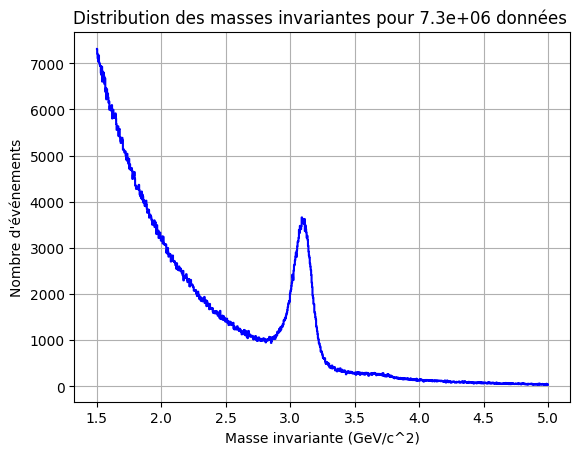

In [4]:
##Bouclage sur les runs
tps = time.time()
#liens = liens[:10] #Pour débuter
results = np.array([])
for lien in liens:
    results = np.concatenate([results, donnees_masses_invarientes(lien)])  #On obtient une liste les données de chaque run 
print("Extraction terminée, on a un total de :", len(results), f"données, ce qui a pris :{(time.time() - tps):.1f} secondes")
graph_masses_invariantes(results)

